# Using the HSC snATAC-seq

In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["SCPRINTER_DATA"] = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/scPrinter/scprinter/docs/reference/Datasets"
import scprinter as scp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import pandas as pd
import numpy as np
import pickle
import torch
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
from scanpy.plotting.palettes import zeileis_28
from tqdm.auto import tqdm
from tqdm.contrib.concurrent import process_map, thread_map
import anndata
import scanpy as sc
import statistics as stat
import json
import csv
import re
import copy
from sklearn.preprocessing import OneHotEncoder

/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. Th

In [2]:
scp.__version__

'1.2.1.dev10+g5ecaa1414'

In this usage, we will test run PRINT/seq2PRINT on the our HSC GW12 cell dataset. We will perform basic single cell analysis such as peak calling, chromVAR, cluster, and UMAP projection, then generate pseudobulks and scale up seq2PRINT taining on all pseudobulks using LoRA. We will also demonstrate how to compute TF binding scores for example regions or a larger number of regions.

## Data preprocessing

First specify the paths and directories we will use. Make sure you use the full absolute path.

In [2]:
# Specify directories we will use. Make sure you provide the full absolute path and not the relative path
main_dir = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo'
work_dir = f'{main_dir}/seq2print'
if not os.path.exists(work_dir):
    os.system("mkdir -p " + work_dir)
frag_dir = f'{main_dir}/fragments'
if not os.path.exists(frag_dir):
    os.system("mkdir -p " + frag_dir)
work_dir

'/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print'

### Load ATAC fragments, create scprinter object & preprocessing

In [3]:
# Load the fragments file
import snapatac2 as snap
os.environ['SNAP_DATA_DIR'] = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo'
samples = ["GW6", "GW12", "GW7", "GW9", "GW10", "GW16", "GW17", "GW20"]
fragment_files = [
    '/cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW7/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW12/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW6/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW9/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW10/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW17/outs/atac_fragments.tsv.gz',
    '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz'
 ]
anno = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Oligo/atac-meta.csv", index_col=0)
barcodes_list = []
for sample in samples:
    sample_barcodes = anno[anno['sample2'] == sample]['barcode2'].tolist()
    barcodes_list.append(sample_barcodes)
# Specify the reference genome. This must match that of your ATAC fragments file
genome = scp.genome.hg38

In [5]:
# Initialize the scPrinter object
# When you finish using the object, run printer.close() otherwise you won't be able to load it properly next time.
import time
start = time.time()
printer_path = os.path.join(work_dir, 'HSC_snATAC_oligo_scprinter.h5ad')

if os.path.exists(printer_path):
    printer = scp.load_printer(f'{work_dir}/HSC_snATAC_oligo_scprinter.h5ad', genome)
else:
    # Load data from the fragments file. Needs at least theses four columns: chromosome, start, end, cell barcode
    printer = scp.pp.import_fragments(
                            path_to_frags=fragment_files, 
                            barcodes=barcodes_list,
                            sample_names=samples,
                            savename=printer_path,
                            genome=genome,
                            min_num_fragments=1000, min_tsse=7,
                            sorted_by_barcode=False, 
                            low_memory=False,
                            )

printer
# printer = scp.load_printer(f'{work_dir}/HSC_snATAC_gw12_scprinter.h5ad', genome)
# printer.close()

head project
AnnData object with n_obs x n_vars = 9282 x 0 backed at '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/HSC_snATAC_oligo_scprinter.h5ad'
    obs: 'sample', 'n_fragment', 'frac_dup', 'frac_mito', 'frag_path', 'frag_sample_name', 'tsse'
    uns: 'bias_path', 'unique_string', 'gff_db', 'binding score', 'footprints', 'reference_sequences', 'bias_bw', 'insertion', 'genome'
    obsm: 'insertion_chr14', 'insertion_chr18', 'insertion_chr2', 'insertion_chr9', 'insertion_chrY', 'insertion_chr1', 'insertion_chr15', 'insertion_chr16', 'insertion_chr11', 'insertion_chr21', 'insertion_chr12', 'insertion_chr22', 'insertion_chr17', 'insertion_chr3', 'insertion_chr4', 'insertion_chr13', 'insertion_chr6', 'insertion_chr8', 'insertion_chr19', 'insertion_chr10', 'insertion_chr20', 'insertion_chrX', 'insertion_chr5', 'insertion_chr7'


In [5]:
printer.obs[:].to_pandas()

/tmp/ipykernel_1389281/2471747555.py:1: DeprecationWarning: `_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'
  printer.obs[:].to_pandas()


,sample,n_fragment,frac_dup,frac_mito,frag_path,frag_sample_name,tsse
0,GW16,8892,0.353920,0.0,/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz,GW16,8.253589
1,GW16,3113,0.367662,0.0,/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz,GW16,8.181818
2,GW16,5883,0.345897,0.0,/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz,GW16,13.524407
3,GW16,7818,0.348174,0.0,/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz,GW16,14.125317
4,GW16,6841,0.341895,0.0,/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz,GW16,14.023961
...,...,...,...,...,...,...,...
9277,GW20,8708,0.388827,0.0,/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz,GW20,15.668449
9278,GW20,8426,0.395899,0.0,/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz,GW20,11.149228
9279,GW20,8288,0.393087,0.0,/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz,GW20,22.992815
9280,GW20,10605,0.390902,0.0,/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz,GW20,14.073200


In [37]:
printer.close()

## Peak calling

Use all barcodes presented, and call peaks. Use the preset “seq2PRINT” to generate peaks that is appropriate to train a seq2PRINT model on. It is recommended to do this, instead of using your predefined peak region to train seq2PRINT

In [35]:
scp.pp.call_peaks(printer=printer,
                  frag_file=fragment_files,
                  cell_grouping=[None], # here we call peaks on the cells that are included in the final analyses
                  group_names=['all'],
                  preset='seq2PRINT', n_jobs=10)
# Fetched the cleaned peaks, save, it will be used in the next step
cleaned_peaks = pd.DataFrame(printer.uns["peak_calling"]['all_cleaned'][:])
cleaned_peaks.to_csv(f'{work_dir}/seq2print_cleaned_narrowPeak.bed',
                     sep='\t', header=False, index=False)

running macs2 with macs2 callpeak --nomodel -t /cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW7/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW12/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW6/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW9/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW10/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW17/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz --outdir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/sc

INFO  @ Wed, 19 Nov 2025 21:00:30: 
# Command line: callpeak --nomodel -t /cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW7/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW12/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW6/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW9/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW10/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW17/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz --outdir /cluster2/huanglab/jiamao/Project/Huma

Reading in peak summit file(s):
NOTE: Assuming all start coordinates are 0-based ..

Padding peak summits by: 500 bp on either side for
Removing peaks overlapping with blacklisted regions and out of bound peaks based on chromosome sizes ..

Filtering overlapping peaks based on peak summit score ..
round: 1 614163 peaks unresolved 604897 peaks selected
round: 2 414 peaks unresolved 399 peaks selected
round: 3 1 peaks unresolved 1 peaks selected
finish clearing
finish sorting
finished summary


/tmp/ipykernel_2779682/1509731943.py:7: DeprecationWarning: `_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'
  cleaned_peaks = pd.DataFrame(printer.uns["peak_calling"]['all_cleaned'][:])


In [36]:
# Call peaks using chromvar preset, this set of peak are recommended to be use as cell x peak for scATAC-seq data, or analysis
scp.pp.call_peaks(printer=printer,
                  frag_file=fragment_files,
                  cell_grouping=[None], # here we call peaks on the cells that are included in the final analyses
                  group_names=['chromvar_all'],
                  preset='chromvar',
                  n_jobs=8,
                  overwrite=False)

# Fetched the cleaned peaks, save, it will be used in the next step
cleaned_peaks = pd.DataFrame(printer.uns["peak_calling"]['chromvar_all_cleaned'][:])
cleaned_peaks.to_csv(f'{work_dir}/regions.bed', 
                     sep='\t', header=False, index=False)

running macs2 with macs2 callpeak --nomodel -t /cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW7/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW12/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW6/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW9/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW10/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW17/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz --outdir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/sc

INFO  @ Wed, 19 Nov 2025 22:10:12: 
# Command line: callpeak --nomodel -t /cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW7/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW12/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW6/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW9/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW10/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW17/outs/atac_fragments.tsv.gz /cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz --outdir /cluster2/huanglab/jiamao/Project/Huma

Reading in peak summit file(s):
NOTE: Assuming all start coordinates are 0-based ..

Padding peak summits by: 400 bp on either side for
Removing peaks overlapping with blacklisted regions and out of bound peaks based on chromosome sizes ..

Filtering overlapping peaks based on peak summit score ..
round: 1 534236 peaks unresolved 274767 peaks selected
round: 2 107142 peaks unresolved 43025 peaks selected
round: 3 27543 peaks unresolved 10340 peaks selected
round: 4 7417 peaks unresolved 2792 peaks selected
round: 5 1951 peaks unresolved 740 peaks selected
round: 6 494 peaks unresolved 190 peaks selected
round: 7 115 peaks unresolved 45 peaks selected
round: 8 30 peaks unresolved 12 peaks selected
round: 9 8 peaks unresolved 4 peaks selected
finish clearing
finish sorting
finished summary


/tmp/ipykernel_2779682/823031148.py:11: DeprecationWarning: `_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'
  cleaned_peaks = pd.DataFrame(printer.uns["peak_calling"]['chromvar_all_cleaned'][:])


## Now let's use scPrinter for some basic exploratory analysis to get a better idea of the dataset

Here we use scPrinter and scanpy for some basic preprocessing and exploratory analysis. Since the purpose of this tutorial is to show you how to run PRINT and seq2PRINT, we are only showing a very simplified version of analysis. For a more complete workflow, you can check out tutorials of commonly used tools such as scanpy (https://scanpy.readthedocs.io/en/stable/tutorials/index.html) or snapatac2 (https://kzhang.org/SnapATAC2/tutorials/pbmc.html). However, this tutorial should be enough to show you how to find the major cell types in our tutorial dataset

### Get peak-by-cell count matrix

In [ ]:
# First construct a peak-by-cell matrix of ATAC counts
peak_path = f'{work_dir}/regions.bed'
adata = scp.pp.make_peak_matrix(printer,
                       regions=peak_path,
                       region_width=500,
                       cell_grouping=None,
                       group_names=None,
                       sparse=True)

Loading insertion profiles


Making peak matrix:   0%|          | 0/228232 [00:00<?, ?it/s]

In [ ]:
adata.write(f'{work_dir}/cell_peak.h5ad')

### Calculate chromVAR motif sores

We have reimplemented chromVAR in scPrinter with significantly improved speed (with GPU speed-up). We now use scPrinter to calculate chromVAR motif scores for each TF in single cells.

In [5]:
# Only keep peaks with > 0 coverage
adata = anndata.read_h5ad(f'{work_dir}/cell_peak.h5ad')
coverage = adata.X.sum(axis=0)
adata = adata[:, coverage > 0]
adata

View of AnnData object with n_obs × n_vars = 9282 × 331903

Before running the below code, make sure you check which GPUs are available (use the nvtop command in terminal).

In [6]:
# We can calculate chromVAR motif scores using either GPU (device = "cuda", much faster) or CPU (device = "cpu", slower)
device = "cuda:1"

if device == "cuda:1":
    import warnings
    warnings.filterwarnings("ignore")
    import scanpy as sc
    import anndata
    import cupy as cp
    import cupyx as cpx
    import time
    import rmm
    from rmm.allocators.cupy import rmm_cupy_allocator
    rmm.reinitialize(
        managed_memory=True, # Allows oversubscription
        pool_allocator=True, # default is False
        devices=0, # GPU device IDs to register. By default registers only GPU 0.
    )
    cp.cuda.set_allocator(rmm_cupy_allocator)

In [ ]:
# Sample background peaks for each peak
scp.chromvar.sample_bg_peaks(adata,
                             genome=genome,
                             method='chromvar',
                             niterations=250)

# Scan motifs
motif = scp.motifs.FigR_Human_Motifs(genome,
                                     bg=list(adata.uns['bg_freq']),
                                     n_jobs=100,
                                     pvalue=5e-5, mode='motifmatchr')
motif.prep_scanner(None, pvalue=5e-5)
motif.chromvar_scan(adata)

# Compute motif scores for single cells
chromvar = scp.chromvar.compute_deviations(adata, chunk_size=50000, device=device)

# Save for later use
chromvar.write(f'{work_dir}/chromvar_cisbp.h5ad')

### Visualize cells on UMAP

In [5]:
chromvar = anndata.read_h5ad(f'{work_dir}/chromvar_cisbp.h5ad')
print(chromvar.X.shape)

(9282, 1141)


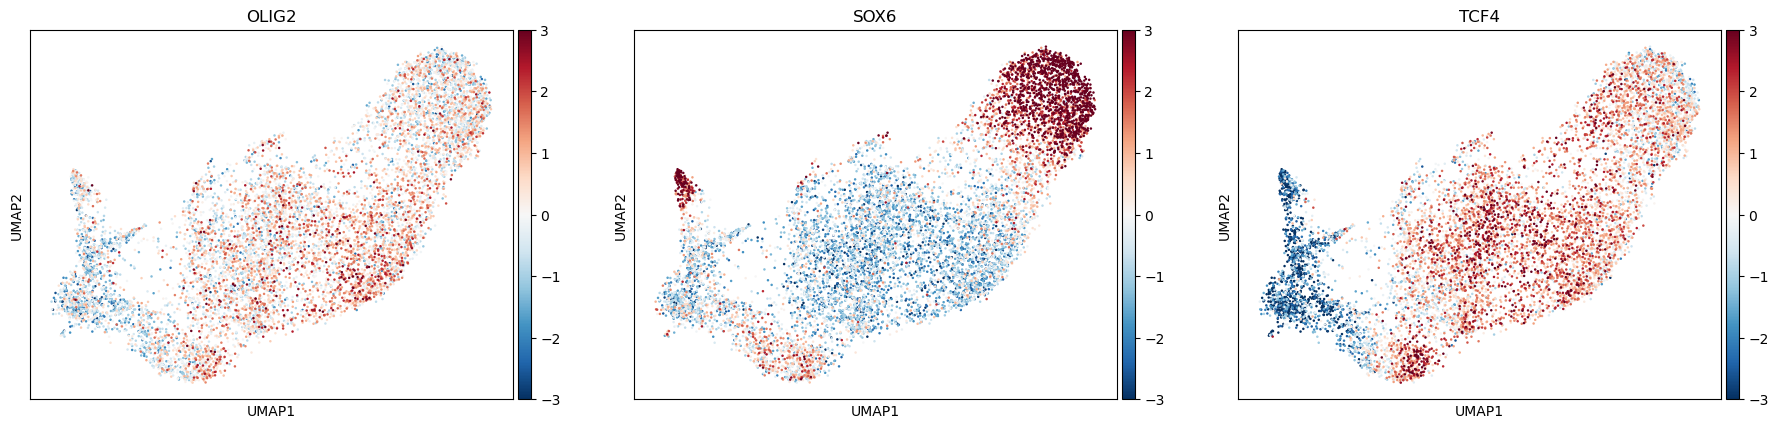

In [6]:
# First perform PCA to get PC loadings
sc.tl.pca(chromvar)

# Using PCA embedding for UMAP projection
from cuml import UMAP
vec = UMAP(metric='cosine').fit_transform(chromvar.obsm["X_pca"])
chromvar.obsm['X_umap'] = vec

# Visualize clusters and cell-type-specific TF motif scores
sc.pl.umap(chromvar, color=['OLIG2', 'SOX6', "TCF4"],cmap='RdBu_r',vmin=-3, vmax=3)

### Clustering of cells using Leiden

In [7]:
chromvar

AnnData object with n_obs × n_vars = 9282 × 1141
    uns: 'pca'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'

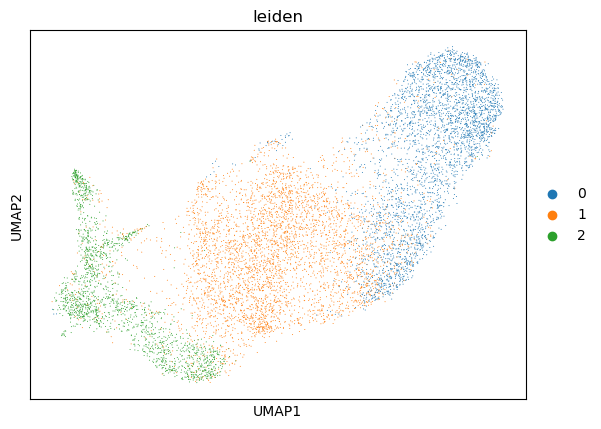

In [8]:
sc.pp.neighbors(chromvar)
sc.tl.leiden(chromvar, flavor="igraph", n_iterations=10, resolution=0.2, random_state=2)
sc.pl.umap(chromvar, color="leiden", size=2)

In [54]:
chromvar.obs

,leiden,sample2,barcode2,celltype,latent_time,UMAP_1,UMAP_2
GW16_AAACAGCCACCTCAGG-1,0,GW16,AAACAGCCACCTCAGG-1,COP,0.543626,1.054473,2.019462
GW16_AAACAGCCAGGATGGC-1,0,GW16,AAACAGCCAGGATGGC-1,COP,0.643846,2.748087,1.803359
GW16_AAACATGCAATAACCT-1,1,GW16,AAACATGCAATAACCT-1,OPC,0.593017,-3.252852,3.004097
GW16_AAACATGCACTAAGTT-1,0,GW16,AAACATGCACTAAGTT-1,MFOL,0.787495,4.881652,2.123666
GW16_AAACCGAAGAACAAGT-1,2,GW16,AAACCGAAGAACAAGT-1,dIPC,0.231255,-1.697736,7.804604
...,...,...,...,...,...,...,...
GW20_TTTGTGGCAAGTCGCT-1,2,GW20,TTTGTGGCAAGTCGCT-1,dIPC,0.339142,-2.470768,7.754126
GW20_TTTGTGGCACGTAATT-1,1,GW20,TTTGTGGCACGTAATT-1,OPC,0.570563,-3.889358,2.368266
GW20_TTTGTGTTCCGCATGA-1,2,GW20,TTTGTGTTCCGCATGA-1,dIPC,0.041512,-1.052731,7.576830
GW20_TTTGTTGGTCACAAAT-1,1,GW20,TTTGTTGGTCACAAAT-1,OPC,0.500779,-3.280301,4.213168


### Label the cell type of each cluster

Here we label the clusters from before annotation by snRNA.

In [9]:
mat = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scanpy/Oligo/oligo_scv_meta.csv', header=0, index_col=0)
mat.index = mat['sample2'] + '_' + mat['barcode2']
mat

,sample2,barcode2,celltype,latent_time,UMAP_1,UMAP_2
GW6_AAACAGCCATCGTTCT-1,GW6,AAACAGCCATCGTTCT-1,NPC,0.702101,0.455401,9.165448
GW6_AAACCGAAGGTCCACA-1,GW6,AAACCGAAGGTCCACA-1,NPC,0.615966,-0.178386,9.287291
GW6_AAAGGACGTGGACCTG-1,GW6,AAAGGACGTGGACCTG-1,NPC,0.585552,-0.143000,8.870684
GW6_AACCGCTCATGTCAGC-1,GW6,AACCGCTCATGTCAGC-1,NPC,0.764052,0.489402,9.257429
GW6_AACCTCCTCAAGGACA-1,GW6,AACCTCCTCAAGGACA-1,NPC,0.610098,-0.004698,9.334385
...,...,...,...,...,...,...
GW20_TTTGTGGCAAGTCGCT-1,GW20,TTTGTGGCAAGTCGCT-1,dIPC,0.339142,-2.470768,7.754126
GW20_TTTGTGGCACGTAATT-1,GW20,TTTGTGGCACGTAATT-1,OPC,0.570563,-3.889358,2.368266
GW20_TTTGTGTTCCGCATGA-1,GW20,TTTGTGTTCCGCATGA-1,dIPC,0.041512,-1.052731,7.576830
GW20_TTTGTTGGTCACAAAT-1,GW20,TTTGTTGGTCACAAAT-1,OPC,0.500779,-3.280301,4.213168


In [10]:
chromvar = chromvar[chromvar.obs.index.isin(mat.index)]
chromvar.obs = chromvar.obs.join(mat)
chromvar

AnnData object with n_obs × n_vars = 9282 × 1141
    obs: 'leiden', 'sample2', 'barcode2', 'celltype', 'latent_time', 'UMAP_1', 'UMAP_2'
    uns: 'pca', 'neighbors', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [11]:
chromvar.obs

,leiden,sample2,barcode2,celltype,latent_time,UMAP_1,UMAP_2
GW16_AAACAGCCACCTCAGG-1,0,GW16,AAACAGCCACCTCAGG-1,COP,0.543626,1.054473,2.019462
GW16_AAACAGCCAGGATGGC-1,0,GW16,AAACAGCCAGGATGGC-1,COP,0.643846,2.748087,1.803359
GW16_AAACATGCAATAACCT-1,1,GW16,AAACATGCAATAACCT-1,OPC,0.593017,-3.252852,3.004097
GW16_AAACATGCACTAAGTT-1,0,GW16,AAACATGCACTAAGTT-1,MFOL,0.787495,4.881652,2.123666
GW16_AAACCGAAGAACAAGT-1,2,GW16,AAACCGAAGAACAAGT-1,dIPC,0.231255,-1.697736,7.804604
...,...,...,...,...,...,...,...
GW20_TTTGTGGCAAGTCGCT-1,2,GW20,TTTGTGGCAAGTCGCT-1,dIPC,0.339142,-2.470768,7.754126
GW20_TTTGTGGCACGTAATT-1,1,GW20,TTTGTGGCACGTAATT-1,OPC,0.570563,-3.889358,2.368266
GW20_TTTGTGTTCCGCATGA-1,2,GW20,TTTGTGTTCCGCATGA-1,dIPC,0.041512,-1.052731,7.576830
GW20_TTTGTTGGTCACAAAT-1,1,GW20,TTTGTTGGTCACAAAT-1,OPC,0.500779,-3.280301,4.213168


In [12]:
chromvar.obs['celltype'].value_counts()

celltype
OPC     3245
COP     2071
MFOL    1317
NPC      940
dIPC     907
MOL      802
Name: count, dtype: int64

... storing 'sample2' as categorical
... storing 'barcode2' as categorical
... storing 'celltype' as categorical


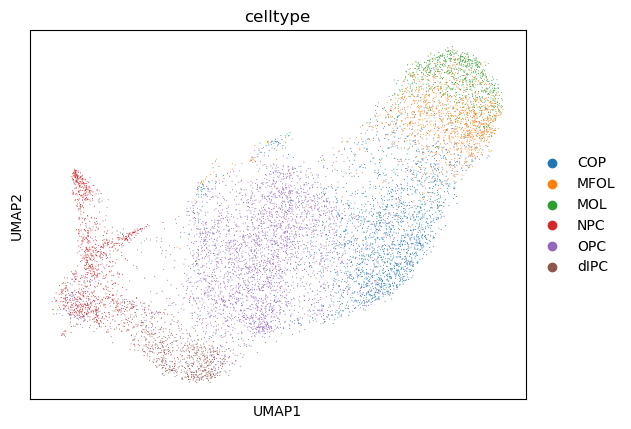

In [13]:
sc.pl.umap(chromvar, color="celltype", size=2)

In [66]:
chromvar

AnnData object with n_obs × n_vars = 9282 × 1141
    obs: 'leiden', 'sample2', 'barcode2', 'celltype', 'latent_time', 'UMAP_1', 'UMAP_2'
    uns: 'pca', 'neighbors', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

## Generation of pseudobulks

We generated 60 pseudobulks proportionally distributed across cell types based on their abundance, with at least one pseudobulk per cell type. For each cell type, we uniformly selected center cells along the latent time continuum, then sequentially added the nearest cells in latent time space until reaching approximately 5 million reads. This approach ensures pseudobulks capture transcriptional heterogeneity across developmental stages while maintaining consistent sequencing depth.

In [97]:
# Calculate total depth per cell
cell_depth = np.array(np.sum(adata.X, axis=1)).squeeze()
threshold = 5e6  # 5M sequencing depth per pseudobulk
target_total_bulks = 60  # Total 60 bulks needed

barcode_groups = []
cell_barcodes = np.array(chromvar.obs.index)
pbulk_centers = []  # Store pseudobulk center indices

# Get all cell types
unique_celltypes = np.unique(chromvar.obs["celltype"])
total_cells = chromvar.shape[0]

# 1. Assign bulk numbers based on cell type proportions
bulk_per_celltype = {}
for celltype in unique_celltypes:
    celltype_cells = np.sum(chromvar.obs["celltype"] == celltype)
    celltype_prop = celltype_cells / total_cells
    # Assign proportionally, at least 1 bulk per cell type
    bulk_count = max(1, round(celltype_prop * target_total_bulks))
    bulk_per_celltype[celltype] = bulk_count

# Adjust total to ensure exactly 60 bulks
total_assigned = sum(bulk_per_celltype.values())
if total_assigned != target_total_bulks:
    # Calculate difference
    diff = target_total_bulks - total_assigned
    if diff > 0:
        # Need to add, prioritize cell types with more cells
        sorted_celltypes = sorted(bulk_per_celltype.items(), 
                                  key=lambda x: np.sum(chromvar.obs["celltype"] == x[0]), 
                                  reverse=True)
        for i in range(diff):
            celltype = sorted_celltypes[i % len(sorted_celltypes)][0]
            bulk_per_celltype[celltype] += 1
    else:
        # Need to reduce, start with cell types with fewer cells
        sorted_celltypes = sorted(bulk_per_celltype.items(), 
                                  key=lambda x: np.sum(chromvar.obs["celltype"] == x[0]))
        for i in range(abs(diff)):
            celltype = sorted_celltypes[i % len(sorted_celltypes)][0]
            if bulk_per_celltype[celltype] > 1:  # Ensure at least 1 bulk remains
                bulk_per_celltype[celltype] -= 1

# 2. Generate bulks for each cell type
bulk_info_records = []
bulk_counter = 0

# Create a mapping from cell index to latent_time
cell_idx_to_latent_time = {}
for idx in range(total_cells):
    cell_idx_to_latent_time[idx] = chromvar.obs["latent_time"].values[idx]

for celltype, target_bulk_count in bulk_per_celltype.items():
    print(f"\nProcessing cell type: {celltype}, target to generate {target_bulk_count} bulks")
    
    # Used to count the number of bulks generated for each cell type
    celltype_bulk_counter = 0

    # Get all cell indices for this cell type
    celltype_mask = (chromvar.obs["celltype"] == celltype)
    celltype_indices = np.where(celltype_mask)[0]
    
    if len(celltype_indices) == 0:
        print(f"  {celltype} has no cells, skipping")
        continue
    
    # Get latent_time for all cells of this cell type
    celltype_latent_times = chromvar.obs["latent_time"].values[celltype_indices]
    
    # Create a mapping from global index to local index
    global_to_local = {global_idx: local_idx for local_idx, global_idx in enumerate(celltype_indices)}
    
    # Sort cells by latent_time
    sorted_idx_by_time = np.argsort(celltype_latent_times)
    sorted_indices = celltype_indices[sorted_idx_by_time]
    sorted_latent_times = celltype_latent_times[sorted_idx_by_time]
    
    # Calculate latent_time range each bulk should cover
    n_bulks = min(target_bulk_count, len(celltype_indices))
    
    # Uniformly select center points within latent_time range
    if n_bulks == 1:
        # If only 1 bulk needed, choose middle position
        center_positions = [len(sorted_indices) // 2]
    else:
        # Uniformly select center point positions
        step = len(sorted_indices) / n_bulks
        center_positions = [int(i * step + step / 2) for i in range(n_bulks)]
        center_positions = [min(pos, len(sorted_indices)-1) for pos in center_positions]
    
    # Generate bulk for each center point
    for i, center_pos in enumerate(center_positions):
        if i >= target_bulk_count:  # Ensure not exceeding target number
            break
            
        center_idx = sorted_indices[center_pos]
        center_latent_time = sorted_latent_times[center_pos]
        
        # Store the pseudobulk center index
        pbulk_centers.append(center_idx)
        
        # Calculate latent_time distance between all cells and the center cell
        time_distances = np.abs(celltype_latent_times - center_latent_time)
        
        # Sort by distance
        distance_sorted_idx = np.argsort(time_distances)
        
        # Select nearest cells until reaching depth threshold
        bulk_members = []
        cumulative_depth = 0
        
        for local_idx in distance_sorted_idx:
            cell_idx = celltype_indices[local_idx]
            cell_depth_value = cell_depth[cell_idx]
            
            if cumulative_depth + cell_depth_value <= threshold:
                bulk_members.append(cell_idx)
                cumulative_depth += cell_depth_value
            else:
                # Add this cell and then stop
                bulk_members.append(cell_idx)
                cumulative_depth += cell_depth_value
                break
        
        # If too few cells selected, try to expand search range
        if len(bulk_members) < 5 and len(bulk_members) < len(celltype_indices):
            # Reselect, allow exceeding threshold
            bulk_members = []
            cumulative_depth = 0
            for local_idx in distance_sorted_idx[:max(20, len(bulk_members)*4)]:  # Select more cells
                cell_idx = celltype_indices[local_idx]
                cell_depth_value = cell_depth[cell_idx]
                bulk_members.append(cell_idx)
                cumulative_depth += cell_depth_value
        
        if len(bulk_members) == 0:
            print(f"  Warning: Could not find enough cells for {celltype} bulk {i+1}")
            continue
        
        bulk_counter += 1
        celltype_bulk_counter += 1 
        
        # Get latent_time of cells in the bulk
        bulk_latent_times = [cell_idx_to_latent_time[idx] for idx in bulk_members]
        bulk_latent_times = np.array(bulk_latent_times)
        
        # Create barcode group
        new_bc_group = pd.DataFrame({
            "barcode": cell_barcodes[bulk_members],
            "group": f"{celltype}_pbulk_{celltype_bulk_counter}",
            "latent_time_center": center_latent_time,
            "total_depth": cumulative_depth,
            "cell_count": len(bulk_members)
        })
        barcode_groups.append(new_bc_group)
        
        # Record bulk information
        bulk_info_records.append({
            'bulk_id': bulk_counter,
            'celltype': celltype,
            'celltype_bulk_id': celltype_bulk_counter,
            'cells': len(bulk_members),
            'total_depth': cumulative_depth,
            'latent_time_center': center_latent_time,
            'latent_time_min': bulk_latent_times.min(),
            'latent_time_max': bulk_latent_times.max(),
            'latent_time_range': bulk_latent_times.max() - bulk_latent_times.min(),
            'center_cell_index': center_idx  # Also store center cell index in summary
        })

barcode_groups = pd.concat(barcode_groups, axis=0)
pbulk_summary = pd.DataFrame(bulk_info_records)

# Save results
barcode_groups.to_csv(f"{work_dir}/barcode_groups_latent_time_based.csv", index=False)
pbulk_summary.to_csv(f"{work_dir}/pbulk_summary_latent_time_based.csv", index=False)


Processing cell type: COP, target to generate 13 bulks

Processing cell type: MFOL, target to generate 9 bulks

Processing cell type: MOL, target to generate 5 bulks

Processing cell type: NPC, target to generate 6 bulks

Processing cell type: OPC, target to generate 21 bulks

Processing cell type: dIPC, target to generate 6 bulks


In [88]:
np.array(pbulk_centers)

array([3887, 6889, 1996, 6519,  894, 2973, 6202, 4789, 1972, 1441,  427,
       5698, 2983, 8343, 7727, 5249, 7093, 7136, 5703, 2388,  683, 1203,
       1583, 5385, 8544, 8081, 8213, 9161, 8982, 2701, 1871, 3927, 3817,
       4302, 1900,  150, 3836, 3414, 6928, 4326,  128, 8822, 8740, 2892,
       2348, 2767, 8126, 8618, 1810, 4845, 2914, 2298,   32, 7243, 9000,
       6670, 5290, 7203, 1833, 8322])

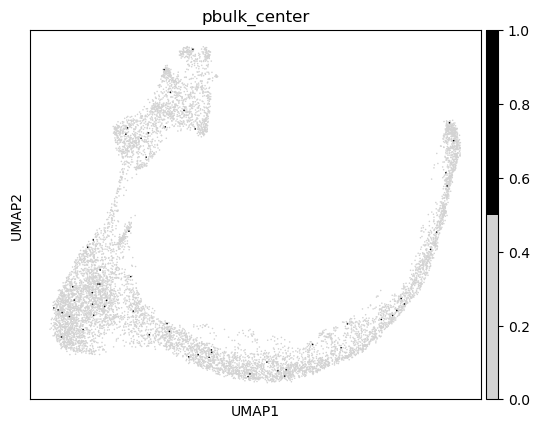

In [92]:
# Plot pseudo-bulk centers on UMAP (black dots are pseudobulk centers)
chromvar.obs["pbulk_center"] = np.zeros(chromvar.shape[0])
chromvar.obs["pbulk_center"][pbulk_centers] = 1
chromvar.obsm['X_umap'] = chromvar.obs[['UMAP_1', 'UMAP_2']].values
import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(['#D3D3D3', 'black'])
sc.pl.umap(chromvar, color="pbulk_center", size=5, cmap=cmap)

In [98]:
barcode_groups

,barcode,group,latent_time_center,total_depth,cell_count
0,GW9_CTTTGAGCATTGACAT-1,COP_pbulk_1,0.394185,5005527.0,805
1,GW16_ACCTACCTCCCGTTGT-1,COP_pbulk_1,0.394185,5005527.0,805
2,GW20_ATATGGTGTTTGAGGC-1,COP_pbulk_1,0.394185,5005527.0,805
3,GW16_CAAGGTTTCCCTGACT-1,COP_pbulk_1,0.394185,5005527.0,805
4,GW16_ATGGCTAGTAACGAGG-1,COP_pbulk_1,0.394185,5005527.0,805
...,...,...,...,...,...
787,GW20_GGACATAAGTGCTGTG-1,dIPC_pbulk_6,0.412110,5006818.0,792
788,GW12_GGAACCACAGCAAGAT-1,dIPC_pbulk_6,0.412110,5006818.0,792
789,GW17_TGTGCGGGTTACAACG-1,dIPC_pbulk_6,0.412110,5006818.0,792
790,GW17_GGAACAATCAAGTGTC-1,dIPC_pbulk_6,0.412110,5006818.0,792


## Training and analyses regarding seq2PRINT trained on the pseudobulk of all cells

We first train a bulk model using all cells, which will be used as the base model for LoRA fine-tuning on individual pseudobulks later

In [ ]:
# Now we generate the config files for training seq2PRINT
import json
model_configs = []
if not os.path.exists(os.path.join(work_dir, 'configs')):
    os.makedirs(os.path.join(work_dir, 'configs'))
for fold in range(2):
    model_config = scp.tl.seq_model_config(
        printer,
        region_path=f'{work_dir}/seq2print_cleaned_narrowPeak.bed',
        cell_grouping=printer.obs_names,
        group_names='HSC_Oligo_Bulk',
        genome=printer.genome,
        fold=fold,
        overwrite_bigwig=False,
        model_name='HSC_Oligo_Bulk',
        additional_config={
            "notes": "v3",
            "tags": ["HSC_Oligo", "Bulk", f"fold{fold}"]
        },
        path_swap=(work_dir, ''),
        config_save_path=f'{work_dir}/configs/HSC_Oligo_fold{fold}.JSON'
    )
    model_configs.append(model_config)

Loading insertion profiles
Creating bigwig for HSC_Oligo_Bulk


  0%|          | 0/24 [00:00<?, ?it/s]

bigwig for HSC_Oligo_Bulk already exists, skip
bigwig for HSC_Oligo_Bulk already exists, skip


Below we generate the commands to run in the terminal to launch our training process. Before launching the training process, it is recommended to install wandb and use it to track the training process. You can first register an account on https://wandb.ai/, then you can activate your mamba/conda environment such as ```mamba activate scprinter```, and install wandb using ```mamba install wandb```. Then you can login via ```wandb login```. This will connect your mamba/conda env with your wandb account. More information on wandb can be found in their quick start guide at https://docs.wandb.ai/quickstart/

Before running the generated commands, you can run ```nvtop``` first to check which GPUs are available. This is especially important when you share the same server with other users. The training job is rather computational intensive and usually one job could take a whole GPU and run overnight. Therefore, we recommend you manually set the CUDA_VISIBLE_DEVICES in the commands to the fully free GPUs.

When you run the command in the terminal, make sure you are in the scprinter mamba environment. To run multiple training jobs in parallel you can add ```&``` to the end of each command, such as ```CUDA_VISIBLE_DEVICES=0 seq2print_train --config /data/mhorlbec/250204_scPrinter_tutorial/PBMC_scATAC_Tutorial//seq2print/configs/PBMC_fold0.JSON --temp_dir /data/mhorlbec/250204_scPrinter_tutorial/PBMC_scATAC_Tutorial//seq2print/temp --model_dir /data/mhorlbec/250204_scPrinter_tutorial/PBMC_scATAC_Tutorial//seq2print/model --data_dir /data/mhorlbec/250204_scPrinter_tutorial/PBMC_scATAC_Tutorial//seq2print --project scPrinter_seq_PBMC --enable_wandb &```

In [59]:
for path in ['temp','model']:
    if not os.path.exists(os.path.join(work_dir, path)):
        os.makedirs(os.path.join(work_dir, path))

for fold in range(2):
    scp.tl.launch_seq2print(
        model_config_path=f'{work_dir}/configs/HSC_Oligo_fold{fold}.JSON',
        temp_dir=f'{work_dir}/temp',
        model_dir=f'{work_dir}/model',
        data_dir=work_dir,
        gpus=fold,  # Change this if you want to specify GPUs to use
        wandb_project='scPrinter_seq_HSC_Oligo_snATAC',  # wandb helps you manage loggins
        verbose=False,
        launch=False  # launch=True would launch the scripts directly
                      # False will just display the commands to copy and run
    )

CUDA_VISIBLE_DEVICES=0 seq2print_train --config /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/configs/HSC_Oligo_fold0.JSON --temp_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/temp --model_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model --data_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print --project scPrinter_seq_HSC_Oligo_snATAC --enable_wandb
CUDA_VISIBLE_DEVICES=1 seq2print_train --config /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/configs/HSC_Oligo_fold1.JSON --temp_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/temp --model_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model --data_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Olig

In [ ]:
conda activate scprinter
export SCPRINTER_DATA="/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/scPrinter/scprinter/docs/reference/Datasets"
export SNAP_DATA_DIR="/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/scPrinter/scprinter/docs/reference/Datasets"
CUDA_VISIBLE_DEVICES=0 seq2print_train --config /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/configs/HSC_Oligo_fold0.JSON --temp_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/temp --model_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model --data_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print --project scPrinter_seq_HSC_Oligo_snATAC --enable_wandb
CUDA_VISIBLE_DEVICES=1 seq2print_train --config /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/configs/HSC_Oligo_fold1.JSON --temp_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/temp --model_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model --data_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print --project scPrinter_seq_HSC_Oligo_snATAC --enable_wandb

## Using the cell embeddings for LoRA fintune seq2PRINT models

In [118]:
# Now fetch models:
import wandb
import json

# Login to your W&B account
wandb.login(key='514639b13a7f497590f661f650fa8c43ac7d69ac')

# Set your entity and project
entity = 'jmliu-xiamen-university'  # Replace with your W&B entity (username or team name)
project = 'scPrinter_seq_HSC_Oligo_snATAC'  # Replace with your W&B project name

# Initialize the API
api = wandb.Api()

# Get the project
runs = api.runs(f"{entity}/{project}")

model_path = []
pretrain_models = []
for run in runs:
    if run.state != 'finished':
        continue
    
    if 'HSC_Oligo' in run.tags and "Bulk" in run.tags:
        run_config = json.loads(run.config)
        model_name = run_config['savename']['value'] + '-' + run.name + '.pt'
        model_path.append(os.path.join(work_dir, "model", model_name))
        pretrain_models.append(model_name)

model_path

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /cluster/home/jiamao/.netrc
wandb: Currently logged in as: jmliu (jmliu-xiamen-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


['/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model/HSC_Oligo_Bulk_fold0-cool-sound-2.pt',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model/HSC_Oligo_Bulk_fold1-likely-wave-3.pt']

In [6]:
barcode_groups = pd.read_csv(f'{work_dir}/barcode_groups_latent_time_based.csv', sep=',', header=0)[['barcode','group']]
barcode_groups

,barcode,group
0,GW9_CTTTGAGCATTGACAT-1,COP_pbulk_1
1,GW16_ACCTACCTCCCGTTGT-1,COP_pbulk_1
2,GW20_ATATGGTGTTTGAGGC-1,COP_pbulk_1
3,GW16_CAAGGTTTCCCTGACT-1,COP_pbulk_1
4,GW16_ATGGCTAGTAACGAGG-1,COP_pbulk_1
...,...,...
48219,GW20_GGACATAAGTGCTGTG-1,dIPC_pbulk_6
48220,GW12_GGAACCACAGCAAGAT-1,dIPC_pbulk_6
48221,GW17_TGTGCGGGTTACAACG-1,dIPC_pbulk_6
48222,GW17_GGAACAATCAAGTGTC-1,dIPC_pbulk_6


In [15]:
cell_grouping, group_names = scp.utils.df2cell_grouping(printer, barcode_groups)

In [56]:
len(cell_grouping)

60

In [16]:
group_names

array(['COP_pbulk_1', 'COP_pbulk_10', 'COP_pbulk_11', 'COP_pbulk_12',
       'COP_pbulk_13', 'COP_pbulk_2', 'COP_pbulk_3', 'COP_pbulk_4',
       'COP_pbulk_5', 'COP_pbulk_6', 'COP_pbulk_7', 'COP_pbulk_8',
       'COP_pbulk_9', 'MFOL_pbulk_1', 'MFOL_pbulk_2', 'MFOL_pbulk_3',
       'MFOL_pbulk_4', 'MFOL_pbulk_5', 'MFOL_pbulk_6', 'MFOL_pbulk_7',
       'MFOL_pbulk_8', 'MFOL_pbulk_9', 'MOL_pbulk_1', 'MOL_pbulk_2',
       'MOL_pbulk_3', 'MOL_pbulk_4', 'MOL_pbulk_5', 'NPC_pbulk_1',
       'NPC_pbulk_2', 'NPC_pbulk_3', 'NPC_pbulk_4', 'NPC_pbulk_5',
       'NPC_pbulk_6', 'OPC_pbulk_1', 'OPC_pbulk_10', 'OPC_pbulk_11',
       'OPC_pbulk_12', 'OPC_pbulk_13', 'OPC_pbulk_14', 'OPC_pbulk_15',
       'OPC_pbulk_16', 'OPC_pbulk_17', 'OPC_pbulk_18', 'OPC_pbulk_19',
       'OPC_pbulk_2', 'OPC_pbulk_20', 'OPC_pbulk_21', 'OPC_pbulk_3',
       'OPC_pbulk_4', 'OPC_pbulk_5', 'OPC_pbulk_6', 'OPC_pbulk_7',
       'OPC_pbulk_8', 'OPC_pbulk_9', 'dIPC_pbulk_1', 'dIPC_pbulk_2',
       'dIPC_pbulk_3', 'dIPC_pbulk_

In [121]:
lora_configs = []
cell_barcodes = np.array(chromvar.obs.index)
embeddings = pd.DataFrame(chromvar.obsm["X_pca"], index=cell_barcodes)
for fold, model in enumerate(pretrain_models):
    lora_config = scp.tl.seq_lora_model_config(printer,
                                            region_path=f'{work_dir}/seq2print_cleaned_narrowPeak.bed',
                                            cell_grouping=cell_grouping,
                                            group_names=group_names,
                                            embeddings=embeddings,
                                            genome=genome,
                                            pretrain_model=f'{work_dir}/model/{model}',
                                            overwrite_barcode=False,
                                            model_name=f'HSC_Oligo_pbulk_LoRA',
                                            fold=fold,
                                            model_config=f'{work_dir}/configs/HSC_Oligo_fold{fold}.JSON',
                                            additional_lora_config={
                                            "lr":3e-5, # put smaller lr for further fintune
                                            "notes": "v3",
                                            "tags": ["HSC_Oligo_pbulk", "LoRA", f"fold{fold}"]},
                                            path_swap=(work_dir, ''),
                                            config_save_path=f'{work_dir}/configs/HSC_Oligo_pbulk_LoRA_fold{fold}.JSON')
    lora_configs.append(lora_config)

Similar to before, we generate the terminal commands to run. Also check ```nvtop``` to select available GPUs and add ```&``` at the end of each command to run them in parallel.

In [122]:
for fold in range(2):
    scp.tl.launch_seq2print(model_config_path=f'{work_dir}/configs/HSC_Oligo_pbulk_LoRA_fold{fold}.JSON',
                            temp_dir=f'{work_dir}/temp',
                            model_dir=f'{work_dir}/model',
                            data_dir=work_dir,
                            gpus=0,
                            wandb_project='scPrinter_seq_HSC_Oligo_snATAC', 
                            verbose=False, 
                            launch=False)

CUDA_VISIBLE_DEVICES=0 seq2print_train --config /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/configs/HSC_Oligo_pbulk_LoRA_fold0.JSON --temp_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/temp --model_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model --data_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print --project scPrinter_seq_HSC_Oligo_snATAC --enable_wandb
CUDA_VISIBLE_DEVICES=0 seq2print_train --config /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/configs/HSC_Oligo_pbulk_LoRA_fold1.JSON --temp_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/temp --model_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model --data_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/

In [ ]:
conda activate scprinter
export SCPRINTER_DATA="/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/scPrinter/scprinter/docs/reference/Datasets"
export SNAP_DATA_DIR="/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/scPrinter/scprinter/docs/reference/Datasets"
# CUDA_VISIBLE_DEVICES=0 seq2print_train --config /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/configs/HSC_Oligo_LoRA_fold0.JSON --temp_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/temp --model_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model --data_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print --project scPrinter_seq_HSC_Oligo_snATAC --enable_wandb
# CUDA_VISIBLE_DEVICES=0 seq2print_train --config /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/configs/HSC_Oligo_LoRA_fold1.JSON --temp_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/temp --model_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model --data_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print --project scPrinter_seq_HSC_Oligo_snATAC --enable_wandb
CUDA_VISIBLE_DEVICES=0 seq2print_train --config /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/configs/HSC_Oligo_pbulk_LoRA_fold0.JSON --temp_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/temp --model_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model --data_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print --project scPrinter_seq_HSC_Oligo_snATAC --enable_wandb
CUDA_VISIBLE_DEVICES=1 seq2print_train --config /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/configs/HSC_Oligo_pbulk_LoRA_fold1.JSON --temp_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/temp --model_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model --data_dir /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print --project scPrinter_seq_HSC_Oligo_snATAC --enable_wandb

In [123]:
printer.close()

In [27]:
printer

head project
Closed AnnData object


## Use seq2PRINT to compute TF binding scores

In [18]:
# Now fetch models:
import wandb
import json # Login to your W&B account
wandb.login(key='514639b13a7f497590f661f650fa8c43ac7d69ac')

# Set your entity and project
entity = 'jmliu-xiamen-university'  # Replace with your W&B entity (username or team name)
project = 'scPrinter_seq_HSC_Oligo_snATAC'  # Replace with your W&B project name

# Initialize the API
api = wandb.Api()

# Get the project
runs = api.runs(f"{entity}/{project}")

lora_models = []
for run in runs:
    if run.state != 'finished':
        continue
    if 'HSC_Oligo_pbulk' in run.tags:
        run_config = json.loads(run.config)
        model_name = run_config['savename']['value'] + '-' + run.name + '.pt'
        lora_models.append(model_name)

lora_model_path = [os.path.join(work_dir, "model", m) for m in lora_models]
lora_model_path

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /cluster/home/jiamao/.netrc


['/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model/HSC_Oligo_pbulk_LoRA_fold0-efficient-sunset-7.pt',
 '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model/HSC_Oligo_pbulk_LoRA_fold1-whole-voice-8.pt']

### Compute TF binding scores for a few example regions

We first select a few example promoter regions that potentially show cell-type specific expression. Let's examine whether seq2PRINT infers differential TF binding at these regions. 

In [19]:
regions_dict = {
    # 'chr11:47378230-47379030': 'SPI1', # Highly expressed in monocytes and B cells

    # 'chr21:33115188-33118388': 'OLIG1', # OPC marker 3k bp-m 3200bp
    'chr21:33115188-33115988': 'OLIG1', # OPC marker 3k bp-0 800bp
    'chr21:33115988-33116788': 'OLIG1', # OPC marker 3k bp-1 800bp
    'chr21:33116788-33117588': 'OLIG1', # OPC marker 3k bp-2 800bp
    'chr21:33117588-33118388': 'OLIG1', # OPC marker 3k bp-3 800bp

}

# Save example regions to a bed file
import re
regions_df = []
for region in regions_dict:
    regions_df.append(re.split("[:-]", region))
regions_df = pd.DataFrame(regions_df)
regions_df.to_csv(f'{work_dir}/regions_olig1.bed',
                  sep='\t', header=False, index=False)

Below we launch the compute for TF binding scores. When we are only testing on a small number of regions or pseudobulks, we can set return_adata to be True so that the results can be returned also in an anndata object. If the number of regions or pseudobulks is big please set it to False so it doesn't take up all the memory.

Remember to check nvtop to select available GPUs using the "gpus" argument.

Note that here we are using ```model_path=lora_model_path[0]``` Which only uses 1 out of the 5 fold models we trained. You can also provide ```model_path=lora_model_path``` Which will use all five fold models. Using all 5 folds will slightly increase accuracy but will take a much longer time. We recommend using only 1 fold for exploratory anlaysis and all 5 folds for final publication.

In [42]:
# selected_groups=['NPC', 'dIPC', 'OPC', 'COP', 'MFOL', 'MOL']
selected_groups=['NPC_pbulk_6', 'NPC_pbulk_5', 'NPC_pbulk_1', 'NPC_pbulk_2', 'NPC_pbulk_3', 'NPC_pbulk_4', 
                 'dIPC_pbulk_1', 'dIPC_pbulk_2', 'dIPC_pbulk_3', 'dIPC_pbulk_4', 'dIPC_pbulk_5', 'dIPC_pbulk_6',
                 'OPC_pbulk_1', 'OPC_pbulk_2', 'OPC_pbulk_3', 'OPC_pbulk_4', 'OPC_pbulk_5', 'OPC_pbulk_6', 'OPC_pbulk_7', 'OPC_pbulk_8', 'OPC_pbulk_9', 'OPC_pbulk_10', 'OPC_pbulk_11', 'OPC_pbulk_12', 'OPC_pbulk_13', 'OPC_pbulk_14', 'OPC_pbulk_15', 'OPC_pbulk_16', 'OPC_pbulk_17', 'OPC_pbulk_18', 'OPC_pbulk_19','OPC_pbulk_20', 'OPC_pbulk_21', 
                 'COP_pbulk_1', 'COP_pbulk_2', 'COP_pbulk_3', 'COP_pbulk_4', 'COP_pbulk_5', 'COP_pbulk_6', 'COP_pbulk_7', 'COP_pbulk_8', 'COP_pbulk_9', 'COP_pbulk_10', 'COP_pbulk_11', 'COP_pbulk_12', 'COP_pbulk_13',
                 'MFOL_pbulk_1', 'MFOL_pbulk_2', 'MFOL_pbulk_3', 'MFOL_pbulk_4', 'MFOL_pbulk_5', 'MFOL_pbulk_6', 'MFOL_pbulk_7', 'MFOL_pbulk_8', 'MFOL_pbulk_9',
                 'MOL_pbulk_1', 'MOL_pbulk_2', 'MOL_pbulk_3', 'MOL_pbulk_4', 'MOL_pbulk_5', 
                 ]

In [43]:
import json
adata_tfbs = scp.tl.seq_tfbs_seq2print(seq_attr_count=None,
                      seq_attr_footprint=None,
                      genome=printer.genome,
                      region_path=f'{work_dir}/regions_olig1.bed',
                      gpus=[1],
                      model_type='lora',
                      model_path=lora_model_path[0], # For now we just run on one fold
                      lora_config=json.load(open(f'{work_dir}/configs/HSC_Oligo_pbulk_LoRA_fold0.JSON', 'r')),
                      group_names=selected_groups,
                      verbose=False,
                      launch=True,
                      return_adata=True,  # First run False -> write BigWig; then True -> return AnnData
                      overwrite_seqattr=True,
                      save_key='HSC_Oligo_LoRA_olig1', # and input a save_key
                      save_path=work_dir)

seq2print_attr --pt /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model/HSC_Oligo_pbulk_LoRA_fold0-efficient-sunset-7.pt --peaks /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/regions_olig1.bed --method shap_hypo --wrapper count --nth_output 0 --gpus 1 --genome hg38 --decay 0.85 --save_key HSC_Oligo_LoRA_olig1 --overwrite --write_numpy --models 32,31,27,28,29,30,54,55,56,57,58,59,33,44,47,48,49,50,51,52,53,34,35,36,37,38,39,40,41,42,43,45,46,0,5,6,7,8,9,10,11,12,1,2,3,4,13,14,15,16,17,18,19,20,21,22,23,24,25,26 --save_names NPC_pbulk_6,NPC_pbulk_5,NPC_pbulk_1,NPC_pbulk_2,NPC_pbulk_3,NPC_pbulk_4,dIPC_pbulk_1,dIPC_pbulk_2,dIPC_pbulk_3,dIPC_pbulk_4,dIPC_pbulk_5,dIPC_pbulk_6,OPC_pbulk_1,OPC_pbulk_2,OPC_pbulk_3,OPC_pbulk_4,OPC_pbulk_5,OPC_pbulk_6,OPC_pbulk_7,OPC_pbulk_8,OPC_pbulk_9,OPC_pbulk_10,OPC_pbulk_11,OPC_pbulk_12,OPC_pbulk_13,OPC_pbulk_14,OPC_pbulk_15,OPC_pbulk_16,OPC_pbulk_17,OPC_pbulk_18,OPC_pbulk_

  0%|          | 0/60 [00:00<?, ?it/s]

seq2print_attr --pt /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model/HSC_Oligo_pbulk_LoRA_fold0-efficient-sunset-7.pt --peaks /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/regions_olig1.bed --method shap_hypo --wrapper just_sum --nth_output 0-30 --gpus 1 --genome hg38 --decay 0.85 --save_key HSC_Oligo_LoRA_olig1 --overwrite --write_numpy --models 32,31,27,28,29,30,54,55,56,57,58,59,33,44,47,48,49,50,51,52,53,34,35,36,37,38,39,40,41,42,43,45,46,0,5,6,7,8,9,10,11,12,1,2,3,4,13,14,15,16,17,18,19,20,21,22,23,24,25,26 --save_names NPC_pbulk_6,NPC_pbulk_5,NPC_pbulk_1,NPC_pbulk_2,NPC_pbulk_3,NPC_pbulk_4,dIPC_pbulk_1,dIPC_pbulk_2,dIPC_pbulk_3,dIPC_pbulk_4,dIPC_pbulk_5,dIPC_pbulk_6,OPC_pbulk_1,OPC_pbulk_2,OPC_pbulk_3,OPC_pbulk_4,OPC_pbulk_5,OPC_pbulk_6,OPC_pbulk_7,OPC_pbulk_8,OPC_pbulk_9,OPC_pbulk_10,OPC_pbulk_11,OPC_pbulk_12,OPC_pbulk_13,OPC_pbulk_14,OPC_pbulk_15,OPC_pbulk_16,OPC_pbulk_17,OPC_pbulk_18,OPC_

  0%|          | 0/60 [00:00<?, ?it/s]

seq2print_tfbs --count_pt /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/scPrinter/scprinter/docs/reference/Datasets/TFBS_0_conv_v2.pt --foot_pt /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/scPrinter/scprinter/docs/reference/Datasets/TFBS_1_conv_v2.pt --seq_count /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model/HSC_Oligo_pbulk_LoRA_fold0-efficient-sunset-7.pt_HSC_Oligo_LoRA_olig1/model_{lora_id}.attr.count.shap_hypo_0_.0.85.npz --seq_foot /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model/HSC_Oligo_pbulk_LoRA_fold0-efficient-sunset-7.pt_HSC_Oligo_LoRA_olig1/model_{lora_id}.attr.just_sum.shap_hypo_0-30_.0.85.npz --genome hg38 --peaks /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/regions_olig1.bed --save_name /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/NPC_pbu

/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. Th

obs=groups, var=regions


Below you can see that seq2PRINT can predict cell-type-specific TF binding consistent with known biology

In [44]:
adata_tfbs

AnnData object with n_obs × n_vars = 60 × 4
    obs: 'save_group_name', 'id', 'group_name'
    var: 'Chromosome', 'Start', 'End', 'identifier'
    obsm: 'chr21:33115188-33115988', 'chr21:33115988-33116788', 'chr21:33116788-33117588', 'chr21:33117588-33118388'

In [45]:
adata_tfbs.obsm

AxisArrays with keys: chr21:33115188-33115988, chr21:33115988-33116788, chr21:33116788-33117588, chr21:33117588-33118388

In [46]:
import pickle

# Save and load the adata_tfbs object
with open(f'{work_dir}/results/HSC_Oligo_pbulk_LoRA_olig1.pkl', 'wb') as f:
    pickle.dump(adata_tfbs, f)

# with open(f'{work_dir}/results/HSC_LoRA_sst_800.pkl', 'rb') as f:
#     adata_tfbs = pickle.load(f)

In [47]:
adata_tfbs.var

,Chromosome,Start,End,identifier
chr21:33115188-33115988,chr21,33115188,33115988,chr21:33115188-33115988
chr21:33115988-33116788,chr21,33115988,33116788,chr21:33115988-33116788
chr21:33116788-33117588,chr21,33116788,33117588,chr21:33116788-33117588
chr21:33117588-33118388,chr21,33117588,33118388,chr21:33117588-33118388


In [48]:
adata_tfbs.obsm

AxisArrays with keys: chr21:33115188-33115988, chr21:33115988-33116788, chr21:33116788-33117588, chr21:33117588-33118388

chr21:33115188-33115988 OLIG1


2025-12-08 17:30:35 - INFO - maxp pruned
2025-12-08 17:30:35 - INFO - cmap pruned
2025-12-08 17:30:35 - INFO - kern dropped
2025-12-08 17:30:35 - INFO - post pruned
2025-12-08 17:30:35 - INFO - FFTM dropped
2025-12-08 17:30:35 - INFO - GPOS pruned
2025-12-08 17:30:35 - INFO - GSUB pruned
2025-12-08 17:30:35 - INFO - glyf pruned
2025-12-08 17:30:35 - INFO - Added gid0 to subset
2025-12-08 17:30:35 - INFO - Added first four glyphs to subset
2025-12-08 17:30:35 - INFO - Closing glyph list over 'GSUB': 30 glyphs before
2025-12-08 17:30:35 - INFO - Glyph names: ['.notdef', '.null', 'C', 'F', 'I', 'L', 'M', 'N', 'O', 'P', 'b', 'd', 'eight', 'five', 'four', 'k', 'l', 'nine', 'nonmarkingreturn', 'one', 'p', 'period', 'seven', 'six', 'space', 'three', 'two', 'u', 'underscore', 'zero']
2025-12-08 17:30:35 - INFO - Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 38, 41, 44, 47, 48, 49, 50, 51, 66, 69, 71, 78, 79, 83, 88]
2025-12-08 17:30:35 - INFO - Closed glyph list over 'G

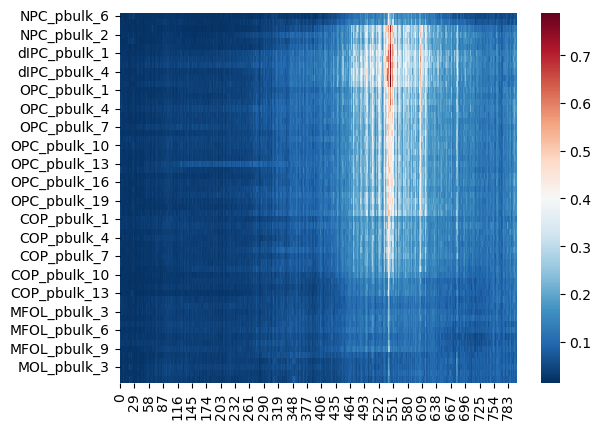

chr21:33115988-33116788 OLIG1


2025-12-08 17:30:40 - INFO - maxp pruned
2025-12-08 17:30:40 - INFO - cmap pruned
2025-12-08 17:30:40 - INFO - kern dropped
2025-12-08 17:30:40 - INFO - post pruned
2025-12-08 17:30:40 - INFO - FFTM dropped
2025-12-08 17:30:40 - INFO - GPOS pruned
2025-12-08 17:30:40 - INFO - GSUB pruned
2025-12-08 17:30:40 - INFO - glyf pruned
2025-12-08 17:30:40 - INFO - Added gid0 to subset
2025-12-08 17:30:40 - INFO - Added first four glyphs to subset
2025-12-08 17:30:40 - INFO - Closing glyph list over 'GSUB': 30 glyphs before
2025-12-08 17:30:40 - INFO - Glyph names: ['.notdef', '.null', 'C', 'F', 'I', 'L', 'M', 'N', 'O', 'P', 'b', 'd', 'eight', 'five', 'four', 'k', 'l', 'nine', 'nonmarkingreturn', 'one', 'p', 'period', 'seven', 'six', 'space', 'three', 'two', 'u', 'underscore', 'zero']
2025-12-08 17:30:40 - INFO - Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 38, 41, 44, 47, 48, 49, 50, 51, 66, 69, 71, 78, 79, 83, 88]
2025-12-08 17:30:40 - INFO - Closed glyph list over 'G

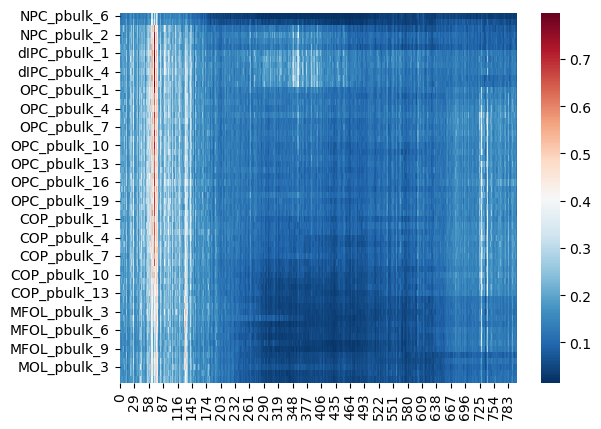

chr21:33116788-33117588 OLIG1


2025-12-08 17:30:45 - INFO - maxp pruned
2025-12-08 17:30:45 - INFO - cmap pruned
2025-12-08 17:30:45 - INFO - kern dropped
2025-12-08 17:30:45 - INFO - post pruned
2025-12-08 17:30:45 - INFO - FFTM dropped
2025-12-08 17:30:45 - INFO - GPOS pruned
2025-12-08 17:30:45 - INFO - GSUB pruned
2025-12-08 17:30:45 - INFO - glyf pruned
2025-12-08 17:30:45 - INFO - Added gid0 to subset
2025-12-08 17:30:45 - INFO - Added first four glyphs to subset
2025-12-08 17:30:45 - INFO - Closing glyph list over 'GSUB': 30 glyphs before
2025-12-08 17:30:45 - INFO - Glyph names: ['.notdef', '.null', 'C', 'F', 'I', 'L', 'M', 'N', 'O', 'P', 'b', 'd', 'eight', 'five', 'four', 'k', 'l', 'nine', 'nonmarkingreturn', 'one', 'p', 'period', 'seven', 'six', 'space', 'three', 'two', 'u', 'underscore', 'zero']
2025-12-08 17:30:45 - INFO - Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 38, 41, 44, 47, 48, 49, 50, 51, 66, 69, 71, 78, 79, 83, 88]
2025-12-08 17:30:45 - INFO - Closed glyph list over 'G

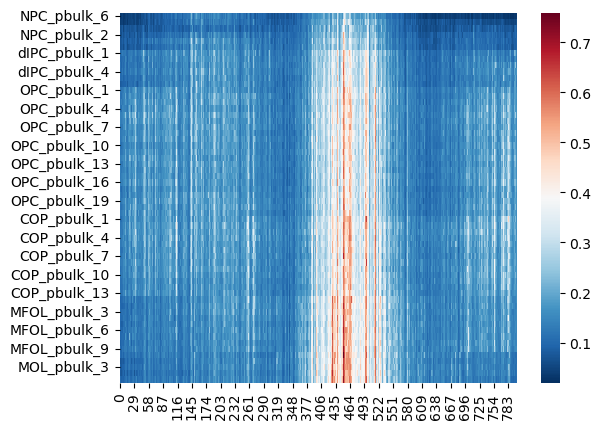

chr21:33117588-33118388 OLIG1


2025-12-08 17:30:49 - INFO - maxp pruned
2025-12-08 17:30:49 - INFO - cmap pruned
2025-12-08 17:30:49 - INFO - kern dropped
2025-12-08 17:30:49 - INFO - post pruned
2025-12-08 17:30:49 - INFO - FFTM dropped
2025-12-08 17:30:49 - INFO - GPOS pruned
2025-12-08 17:30:49 - INFO - GSUB pruned
2025-12-08 17:30:49 - INFO - glyf pruned
2025-12-08 17:30:49 - INFO - Added gid0 to subset
2025-12-08 17:30:49 - INFO - Added first four glyphs to subset
2025-12-08 17:30:49 - INFO - Closing glyph list over 'GSUB': 30 glyphs before
2025-12-08 17:30:49 - INFO - Glyph names: ['.notdef', '.null', 'C', 'F', 'I', 'L', 'M', 'N', 'O', 'P', 'b', 'd', 'eight', 'five', 'four', 'k', 'l', 'nine', 'nonmarkingreturn', 'one', 'p', 'period', 'seven', 'six', 'space', 'three', 'two', 'u', 'underscore', 'zero']
2025-12-08 17:30:49 - INFO - Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 38, 41, 44, 47, 48, 49, 50, 51, 66, 69, 71, 78, 79, 83, 88]
2025-12-08 17:30:49 - INFO - Closed glyph list over 'G

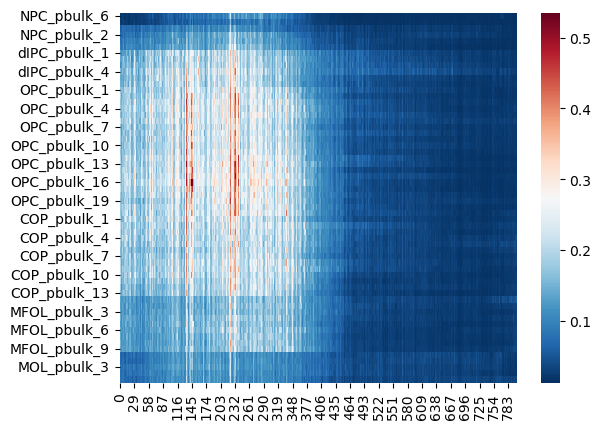

In [49]:
for region in regions_dict.keys():
    print(region, regions_dict[region])
    tfbs = pd.DataFrame(adata_tfbs.obsm[region], index=selected_groups)
    sns.heatmap(tfbs, cmap='RdBu_r')
    plt.savefig(f'{work_dir}/plots/TFBS_pbulk_{region}.pdf')
    plt.show()

### Compute TF binding scores on a larger number of peaks

When we run TF binding score calculation on a large number of peaks, we set return_adata=False and instead save the results only to bigwig files. We can later retrieve the saved scores from these bigwig files. Here, for simplicity, we only select 3 pseudobulks from each cell type to compute TF binding scores for simplicity. For your own dataset, which pseudobulks to include for TF binding prediction depends on (1) how biologically different you think the pseudobulks will be and (2) how much computational resource you have. In our experience, calculating TF binding scores on 70k regions for 9 pseudobulks on 8 GPUs takes roughly overnight.

#### Extracting and analyzing TF binsing scores

In [50]:
# We first scan TF motifs across all regions to find motif matched sites

# Initialize motif set object
motifs = scp.motifs.FigR_Human_Motifs(genome=genome, bg=[0.25] * 4)

# Prepare motif scanner. Here you can specify which TF motifs you want to scan using tf_genes. If tf_genes=None then use all motifs
motifs.prep_scanner()

regions_light = pd.read_csv(f'{work_dir}/regions_olig1.bed', sep='\t', header=None)
# Scan motif sites. This will return the exact genomic coordinates of motif matches
motif_sites = motifs.scan_motif(regions_light, verbose=True, clean=True)

# Reformat motif matches to a pandas DataFrame
motif_sites = pd.DataFrame(motif_sites)
motif_sites.iloc[:, 2] = motif_sites.iloc[:, 1] + motif_sites.iloc[:, 8]
motif_sites.iloc[:, 1] = motif_sites.iloc[:, 1] + motif_sites.iloc[:, 7]
motif_sites = motif_sites.iloc[:, [0,1,2,4]]
motif_sites.columns=["chrom", "start", "end", "TF"]
motif_sites

  0%|          | 0/8 [00:00<?, ?it/s]

,chrom,start,end,TF
0,chr21,33115719,33115733,CTCF
1,chr21,33115227,33115241,FOXE3
2,chr21,33115231,33115239,FOXH1
3,chr21,33115979,33115987,GCM1
4,chr21,33115978,33115987,GCM2
...,...,...,...,...
542,chr21,33117900,33117929,ZNF782
543,chr21,33117832,33117902,ZNF785
544,chr21,33117849,33117890,ZNF805
545,chr21,33117853,33117889,ZNF821


In [51]:
# We then extract the TF binding scores at those motif sites. This might take a bit longer (~10min) if you use all TFs
def fetch_bw(args):
    import pyBigWig as pw
    import numpy as np
    from tqdm import tqdm
    
    TFBS, bw, chrom_sizes = args
    chroms, starts, ends = np.array(TFBS['chrom']), np.array(TFBS['start']), np.array(TFBS['end'])
    
    vs = []
    try:
        with pw.open(bw, 'r') as f:
            bw_chroms = f.chroms()  # Chromosomes present in BigWig
            
            for chr, left, right in zip(tqdm(chroms, desc="Processing sites"), starts, ends):
                if chr not in bw_chroms:
                    vs.append(np.nan)
                    continue
                    
                try:
                    # Fetch interval stats without full chrom read
                    scores = f.values(chr, left, right, numpy=True)
                    vs.append(np.nanmean(scores) if scores is not None else np.nan)
                except:
                    vs.append(np.nan)
                    
    except Exception as e:
        print(f"Error processing {bw}: {str(e)}")
        vs = [np.nan] * len(chroms)
        
    return vs

# Multi-process loading of TF binding scores 
samples = selected_groups
bigwig_dict = {sample:f"{work_dir}/{sample}_TFBS.bigwig" for sample in samples}
chrom_sizes = genome.chrom_sizes
args = [[motif_sites, bigwig_dict[sample], chrom_sizes] for sample in samples]
n_jobs = 4


import multiprocessing as mp
with mp.Pool(n_jobs) as pool:
    TFBS_scores = list(pool.imap(fetch_bw, args))

TFBS_scores = np.array(TFBS_scores).T
TFBS_scores = pd.DataFrame(TFBS_scores, columns=[f"TFBS_{sample}" for sample in samples])
TFBS_scores = pd.concat([motif_sites, TFBS_scores], axis=1)

Processing sites: 100%|██████████| 547/547 [00:00<00:00, 6484.64it/s]


Exception in thread Thread-64 (bg_main):
Traceback (most recent call last):
  File "/tmp/ipykernel_2474676/440942844.py", line 17, in bg_main
  File "/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/IPython/core/display_functions.py", line 354, in update
    update_display(obj, display_id=self.display_id, **kwargs)
  File "/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/IPython/core/display_functions.py", line 306, in update_display
    display(obj, display_id=display_id, **kwargs)
  File "/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/IPython/core/display_functions.py", line 276, in display
    publish_display_data(data=obj, metadata=metadata, **kwargs)
  File "/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/IPython/core/display_functions.py", line 73, in publish_display_data
    display_pub.publish(
  File "/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-

In [52]:
TFBS_scores.head()

,chrom,start,end,TF,TFBS_NPC_pbulk_6,TFBS_NPC_pbulk_5,TFBS_NPC_pbulk_1,TFBS_NPC_pbulk_2,TFBS_NPC_pbulk_3,TFBS_NPC_pbulk_4,...,TFBS_MFOL_pbulk_5,TFBS_MFOL_pbulk_6,TFBS_MFOL_pbulk_7,TFBS_MFOL_pbulk_8,TFBS_MFOL_pbulk_9,TFBS_MOL_pbulk_1,TFBS_MOL_pbulk_2,TFBS_MOL_pbulk_3,TFBS_MOL_pbulk_4,TFBS_MOL_pbulk_5
0,chr21,33115719,33115733,CTCF,0.121341,0.167784,0.363901,0.356043,0.341438,0.376153,...,0.088445,0.094302,0.073444,0.085494,0.079193,0.051440,0.051564,0.051543,0.051441,0.056454
1,chr21,33115227,33115241,FOXE3,0.021197,0.017997,0.026121,0.019644,0.022413,0.019516,...,0.028000,0.024235,0.022834,0.025332,0.029608,0.024606,0.019561,0.022192,0.027721,0.020127
2,chr21,33115231,33115239,FOXH1,0.019769,0.017890,0.028587,0.020529,0.021715,0.019891,...,0.028679,0.024297,0.023417,0.024805,0.029916,0.025153,0.019986,0.023147,0.028799,0.020579
3,chr21,33115979,33115987,GCM1,0.096348,0.119522,0.164499,0.171925,0.174038,0.170504,...,0.127042,0.132589,0.120795,0.127280,0.124039,0.134681,0.131420,0.128031,0.131026,0.134712
4,chr21,33115978,33115987,GCM2,0.095155,0.116590,0.159038,0.165281,0.166089,0.163251,...,0.123862,0.128305,0.117910,0.123678,0.120790,0.131304,0.128867,0.125726,0.127496,0.131523


In [53]:
TFBS_scores.to_csv(f'{work_dir}/results/TFBS_pbulk_scores_olig1.csv', index=False)

In [36]:
printer.close()

We hope this tutorial is helpful for you and if you run into any issues please feel free to open a GitHub issue at https://github.com/buenrostrolab/scPrinter!

# Quick inspection

In [7]:
barcode_groups

,barcode,group
0,GW9_CTTTGAGCATTGACAT-1,COP_pbulk_1
1,GW16_ACCTACCTCCCGTTGT-1,COP_pbulk_1
2,GW20_ATATGGTGTTTGAGGC-1,COP_pbulk_1
3,GW16_CAAGGTTTCCCTGACT-1,COP_pbulk_1
4,GW16_ATGGCTAGTAACGAGG-1,COP_pbulk_1
...,...,...
48219,GW20_GGACATAAGTGCTGTG-1,dIPC_pbulk_6
48220,GW12_GGAACCACAGCAAGAT-1,dIPC_pbulk_6
48221,GW17_TGTGCGGGTTACAACG-1,dIPC_pbulk_6
48222,GW17_GGAACAATCAAGTGTC-1,dIPC_pbulk_6


In [8]:
selected_groups=['NPC_pbulk_6', 'NPC_pbulk_5', 'NPC_pbulk_1', 'NPC_pbulk_2', 'NPC_pbulk_3', 'NPC_pbulk_4', 
                 'dIPC_pbulk_1', 'dIPC_pbulk_2', 'dIPC_pbulk_3', 'dIPC_pbulk_4', 'dIPC_pbulk_5', 'dIPC_pbulk_6',
                 'OPC_pbulk_1', 'OPC_pbulk_2', 'OPC_pbulk_3', 'OPC_pbulk_4', 'OPC_pbulk_5', 'OPC_pbulk_6', 'OPC_pbulk_7', 'OPC_pbulk_8', 'OPC_pbulk_9', 'OPC_pbulk_10', 'OPC_pbulk_11', 'OPC_pbulk_12', 'OPC_pbulk_13', 'OPC_pbulk_14', 'OPC_pbulk_15', 'OPC_pbulk_16', 'OPC_pbulk_17', 'OPC_pbulk_18', 'OPC_pbulk_19','OPC_pbulk_20', 'OPC_pbulk_21', 
                 'COP_pbulk_1', 'COP_pbulk_2', 'COP_pbulk_3', 'COP_pbulk_4', 'COP_pbulk_5', 'COP_pbulk_6', 'COP_pbulk_7', 'COP_pbulk_8', 'COP_pbulk_9', 'COP_pbulk_10', 'COP_pbulk_11', 'COP_pbulk_12', 'COP_pbulk_13',
                 'MFOL_pbulk_1', 'MFOL_pbulk_2', 'MFOL_pbulk_3', 'MFOL_pbulk_4', 'MFOL_pbulk_5', 'MFOL_pbulk_6', 'MFOL_pbulk_7', 'MFOL_pbulk_8', 'MFOL_pbulk_9',
                 'MOL_pbulk_1', 'MOL_pbulk_2', 'MOL_pbulk_3', 'MOL_pbulk_4', 'MOL_pbulk_5', 
                 ]

In [9]:
cell_grouping = []
for group in selected_groups:
    barcodes_in_group = barcode_groups[barcode_groups['group'] == group]['barcode'].tolist()
    cell_grouping.append(barcodes_in_group)

In [124]:
scp.tl.get_footprint_score(printer,
                       save_key='oligo1_region',
                       cell_grouping=cell_grouping,
                       group_names=selected_groups,
                       regions = ["chr21:33115188-33115988", "chr21:33115988-33116788", "chr21:33116788-33117588", "chr21:33117588-33118388"], 
                       n_jobs=20,
                       backed=True, 
                       overwrite=True)

estimated file size: 0.07 GB
Creating oligo1_region in printer.footprintsadata
obs=groups, var=regions
266 100


Submitting jobs:   0%|          | 0/396 [00:00<?, ?it/s]

collecting multi-scale footprints:   0%|          | 0/396 [00:00<?, ?it/s]

In [117]:
printer

head project
AnnData object with n_obs x n_vars = 9282 x 0 backed at '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/HSC_snATAC_oligo_scprinter.h5ad'
    obs: 'sample', 'n_fragment', 'frac_dup', 'frac_mito', 'frag_path', 'frag_sample_name', 'tsse'
    uns: 'bias_path', 'unique_string', 'gff_db', 'binding score', 'footprints', 'reference_sequences', 'bias_bw', 'insertion', 'genome'
    obsm: 'insertion_chr14', 'insertion_chr18', 'insertion_chr2', 'insertion_chr9', 'insertion_chrY', 'insertion_chr1', 'insertion_chr15', 'insertion_chr16', 'insertion_chr11', 'insertion_chr21', 'insertion_chr12', 'insertion_chr22', 'insertion_chr17', 'insertion_chr3', 'insertion_chr4', 'insertion_chr13', 'insertion_chr6', 'insertion_chr8', 'insertion_chr19', 'insertion_chr10', 'insertion_chr20', 'insertion_chrX', 'insertion_chr5', 'insertion_chr7'
detected 1 footprintsadata
name oligo1_region
AnnData object with n_obs x n_vars = 60 x 4 backed at '/cluster2/huanglab/

<Axes: >

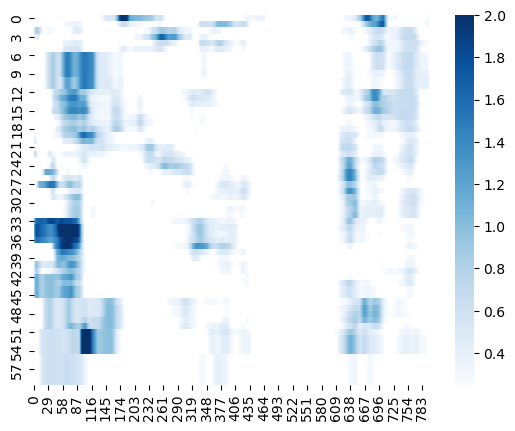

In [ ]:
footprint_adata = printer.footprintsadata['oligo1_region']
footprints = footprint_adata.obsm["chr21:33115188-33115988"] # "chr21:33115988-33116788", "chr21:33116788-33117588", "chr21:33117588-33118388"
fp = footprints[:, 70, 0:800].copy()
fp[fp <= 0.25] = np.nan
sns.heatmap(fp, cmap='Blues', vmin=0.25, vmax=2.0)

In [136]:
regions = ["chr21:33115188-33115988", "chr21:33115988-33116788", "chr21:33116788-33117588", "chr21:33117588-33118388"]

2025-12-08 23:23:22 - INFO - maxp pruned
2025-12-08 23:23:22 - INFO - cmap pruned
2025-12-08 23:23:22 - INFO - kern dropped
2025-12-08 23:23:22 - INFO - post pruned
2025-12-08 23:23:22 - INFO - FFTM dropped
2025-12-08 23:23:22 - INFO - GPOS pruned
2025-12-08 23:23:22 - INFO - GSUB pruned
2025-12-08 23:23:22 - INFO - glyf pruned
2025-12-08 23:23:22 - INFO - Added gid0 to subset
2025-12-08 23:23:22 - INFO - Added first four glyphs to subset
2025-12-08 23:23:22 - INFO - Closing glyph list over 'GSUB': 15 glyphs before
2025-12-08 23:23:22 - INFO - Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one', 'period', 'seven', 'six', 'space', 'three', 'two', 'zero']
2025-12-08 23:23:22 - INFO - Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
2025-12-08 23:23:22 - INFO - Closed glyph list over 'GSUB': 15 glyphs after
2025-12-08 23:23:22 - INFO - Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one',

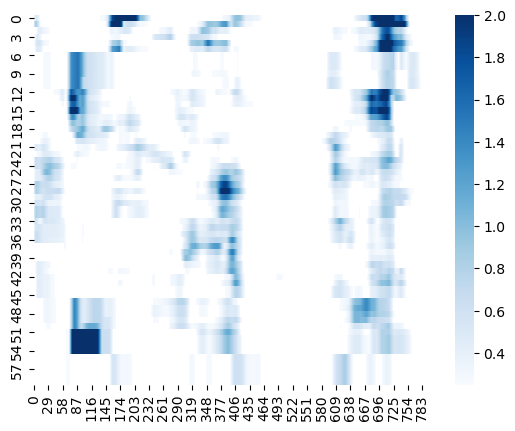

2025-12-08 23:23:26 - INFO - maxp pruned
2025-12-08 23:23:26 - INFO - cmap pruned
2025-12-08 23:23:26 - INFO - kern dropped
2025-12-08 23:23:26 - INFO - post pruned
2025-12-08 23:23:26 - INFO - FFTM dropped
2025-12-08 23:23:26 - INFO - GPOS pruned
2025-12-08 23:23:26 - INFO - GSUB pruned
2025-12-08 23:23:26 - INFO - glyf pruned
2025-12-08 23:23:26 - INFO - Added gid0 to subset
2025-12-08 23:23:26 - INFO - Added first four glyphs to subset
2025-12-08 23:23:26 - INFO - Closing glyph list over 'GSUB': 15 glyphs before
2025-12-08 23:23:26 - INFO - Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one', 'period', 'seven', 'six', 'space', 'three', 'two', 'zero']
2025-12-08 23:23:26 - INFO - Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
2025-12-08 23:23:26 - INFO - Closed glyph list over 'GSUB': 15 glyphs after
2025-12-08 23:23:26 - INFO - Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one',

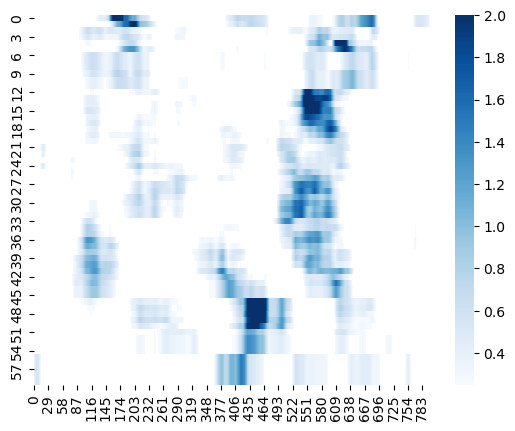

2025-12-08 23:23:29 - INFO - maxp pruned
2025-12-08 23:23:29 - INFO - cmap pruned
2025-12-08 23:23:29 - INFO - kern dropped
2025-12-08 23:23:29 - INFO - post pruned
2025-12-08 23:23:29 - INFO - FFTM dropped
2025-12-08 23:23:29 - INFO - GPOS pruned
2025-12-08 23:23:29 - INFO - GSUB pruned
2025-12-08 23:23:30 - INFO - glyf pruned
2025-12-08 23:23:30 - INFO - Added gid0 to subset
2025-12-08 23:23:30 - INFO - Added first four glyphs to subset
2025-12-08 23:23:30 - INFO - Closing glyph list over 'GSUB': 15 glyphs before
2025-12-08 23:23:30 - INFO - Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one', 'period', 'seven', 'six', 'space', 'three', 'two', 'zero']
2025-12-08 23:23:30 - INFO - Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
2025-12-08 23:23:30 - INFO - Closed glyph list over 'GSUB': 15 glyphs after
2025-12-08 23:23:30 - INFO - Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one',

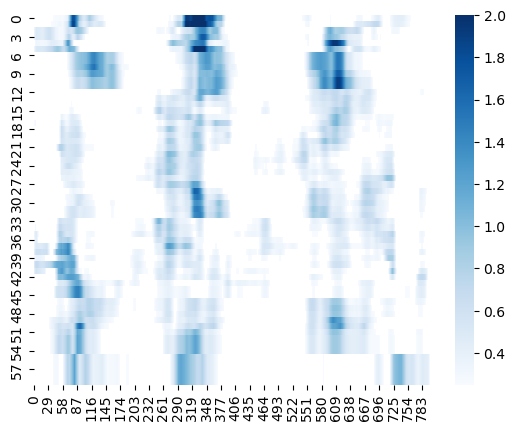

2025-12-08 23:23:33 - INFO - maxp pruned
2025-12-08 23:23:33 - INFO - cmap pruned
2025-12-08 23:23:33 - INFO - kern dropped
2025-12-08 23:23:33 - INFO - post pruned
2025-12-08 23:23:33 - INFO - FFTM dropped
2025-12-08 23:23:33 - INFO - GPOS pruned
2025-12-08 23:23:33 - INFO - GSUB pruned
2025-12-08 23:23:33 - INFO - glyf pruned
2025-12-08 23:23:33 - INFO - Added gid0 to subset
2025-12-08 23:23:33 - INFO - Added first four glyphs to subset
2025-12-08 23:23:33 - INFO - Closing glyph list over 'GSUB': 15 glyphs before
2025-12-08 23:23:33 - INFO - Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one', 'period', 'seven', 'six', 'space', 'three', 'two', 'zero']
2025-12-08 23:23:33 - INFO - Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
2025-12-08 23:23:33 - INFO - Closed glyph list over 'GSUB': 15 glyphs after
2025-12-08 23:23:33 - INFO - Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one',

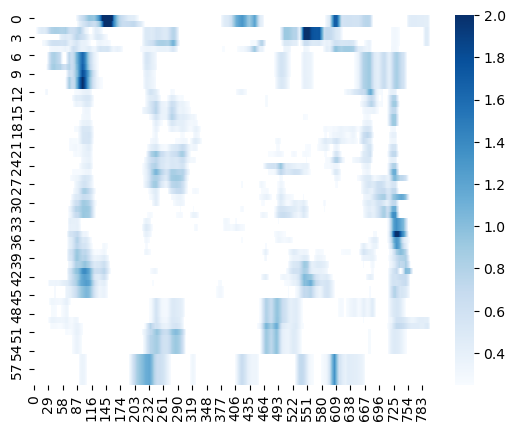

In [137]:
for region in regions:
    footprints = footprint_adata.obsm[region] # "chr21:33115988-33116788", "chr21:33116788-33117588", "chr21:33117588-33118388"
    fp = footprints[:, 70, 0:800].copy()
    fp[fp <= 0.25] = np.nan
    sns.heatmap(fp, cmap='Blues', vmin=0.25, vmax=2.0)
    plt.savefig(f'{work_dir}/plots/footprint_pbulk_{region}.pdf')
    plt.show()

In [138]:
printer.close()